What Stage 4 does and why it's structured this waySIMP (Solid Isotropic Material with Penalization) is the topology optimization algorithm. It starts with a uniform density field across all elements — every element is 50% material — and iteratively updates it by solving the FEA problem, computing sensitivities (how much does compliance change if I remove a tiny bit of material here?), and shifting density toward 0 (void) or 1 (solid) based on those sensitivities.The key insight is the penalization: density is raised to a power p (typically 3) before being multiplied into the stiffness. This makes intermediate densities mechanically inefficient — an element at 0.5 density has only 0.5³ = 0.125 of its full stiffness, so the optimizer is pushed toward binary 0/1 solutions rather than a grey mush.The data flow for this stage is:outputs/meshes/<name>_stage03.json       ← handoff from Stage 3
outputs/meshes/<name>.xdmf              ← mesh (re-used for FEA iterations)
outputs/meshes/<name>_boundaries.xdmf   ← BCs (re-used each iteration)
        ↓
src/optimization/density_filter.py       ← smooths density to avoid checkerboard
src/optimization/simp.py                 ← optimization loop
        ↓
outputs/meshes/<name>_density.xdmf       ← final density field
outputs/reports/<name>_density_*.png     ← renders at each checkpoint
outputs/reports/<name>_convergence.png   ← compliance history plot
outputs/meshes/<name>_stage04.json       ← handoff to Stage 5The split between density_filter.py and simp.py is load-bearing — without the filter, SIMP produces checkerboard instability (alternating solid/void elements in a checkerboard pattern that has artificially high stiffness but is physically unmakeable). The filter is what makes the result printable.

Cell 0 — Parameters (tag: parameters)

In [8]:
# Cell 0 — tagged: parameters
import os
os.chdir("/workspace")

import sys
sys.path.insert(0, "/workspace")

PART_NAME_OVERRIDE = None   # set by pipeline_full.ipynb in sweep mode

STAGE03_HANDOFF   = None    # auto-detect if None
VOLUME_FRACTION   = 0.45     # retain 40% of original material
PENAL             = 3.0     # penalization exponent — don't go below 2.5
FILTER_RADIUS     = 8.0     # mm — should be ~3x target_element_size
MAX_ITERATIONS    = 200
CONVERGENCE_TOL   = 0.002
MOVE_LIMIT        = 0.05     # OC max density change per iteration
CHECKPOINT_EVERY  = 10      # render + save density every N iterations
USE_ITERATIVE_SOLVER = False
RENDER_PLOTS = False

Cell 1 — Load Stage 3 handoff

In [9]:
# Cell 1 — Use uniform optimization domain mesh directly
from pathlib import Path
import json

xdmf_path       = Path("outputs/meshes/opt_domain.xdmf")
boundaries_xdmf = Path("outputs/meshes/opt_domain_boundaries.xdmf")
part_name = PART_NAME_OVERRIDE if PART_NAME_OVERRIDE else "base_part"
from src.geometry.param_schema import PipelineParams, BoundaryConditions
pipeline_params = PipelineParams.from_json("scad/params.json")
geometry_params = pipeline_params.geometry
load_hints      = {
    "primary_face":     pipeline_params.load_hints.primary_face,
    "load_magnitude_n": pipeline_params.load_hints.load_magnitude_n,
}
material        = {"youngs_modulus_pa": 210e9, "poissons_ratio": 0.3, "name": "steel"}
baseline_sf     = 99.0

assert xdmf_path.exists(), f"Not found: {xdmf_path}"
assert boundaries_xdmf.exists(), f"Not found: {boundaries_xdmf}"
print(f"Using uniform optimization mesh: {xdmf_path}")

# Load full params — geometry_params drives the disk BC predicate for corner BCs
from src.geometry.param_schema import PipelineParams, BoundaryConditions
pipeline_params = PipelineParams.from_json("scad/params.json")
geometry_params = pipeline_params.geometry
bc_params = BoundaryConditions(
    fixed_face="corners",       # disk predicate centred on each mounting hole
    load_face="top",
    load_direction=[0.0, 0.0, -1.0],
    hole_inset_fraction=0.15,   # fallback only — disk predicate used when geometry_params present
    shell_thickness_mm=2.0,
)
print(f"BCs: fixed='{bc_params.fixed_face}', load='{bc_params.load_face}'")
print(f"Hole geometry: dia={geometry_params.mounting_hole_diameter}mm, "
      f"inset={geometry_params.mounting_hole_inset}mm")

Using uniform optimization mesh: outputs/meshes/opt_domain.xdmf
BCs: fixed='corners', load='top'
Hole geometry: dia=6.0mm, inset=10.0mm


Cell 2 — Configure SIMP

In [10]:
# Cell 2 — Build SIMP config — two-stage penalization continuation
#
# Stage 1 (soft): low penalization lets topology develop freely
# Stage 2 (hard): higher penalization commits the topology to 0/1
# This prevents the optimizer from switching between equivalent local minima.
from src.optimization.simp import SIMPConfig

config_soft = SIMPConfig(
    volume_fraction  = VOLUME_FRACTION,
    penal            = 2.0,           # soft — intermediate densities allowed
    filter_radius    = FILTER_RADIUS,
    max_iterations   = 40,
    # With OC damping η=0.5, max achievable rho_change = 0.5 × move = 0.05.
    # Setting tol = 0.05 fires on iteration 1. Use 0.5 here so the
    # compliance-flat check (iter > 10, rel_spread < 1e-4) is the real
    # Stage 1 convergence signal; this is a backstop only.
    convergence_tol  = 0.5,
    move             = 0.1,
    checkpoint_every = CHECKPOINT_EVERY,
)

config_hard = SIMPConfig(
    volume_fraction  = VOLUME_FRACTION,
    penal            = 3.0,           # hard — drives to binary
    filter_radius    = FILTER_RADIUS,
    max_iterations   = 120,
    convergence_tol  = 0.002,
    move             = 0.05,
    checkpoint_every = CHECKPOINT_EVERY,
)

print("SIMP continuation strategy:")
print(f"  Stage 1 — penal={config_soft.penal}, "
      f"move={config_soft.move}, "
      f"max_iter={config_soft.max_iterations}")
print(f"  Stage 2 — penal={config_hard.penal}, "
      f"move={config_hard.move}, "
      f"max_iter={config_hard.max_iterations}")
print(f"  Filter radius:   {FILTER_RADIUS} mm")
print(f"  Volume fraction: {VOLUME_FRACTION}")

SIMP continuation strategy:
  Stage 1 — penal=2.0, move=0.1, max_iter=40
  Stage 2 — penal=3.0, move=0.05, max_iter=120
  Filter radius:   8.0 mm
  Volume fraction: 0.45


Cell 3 — Run optimization

In [11]:
# Cell 3 — Run SIMP continuation loop (two stages)
import numpy as np
import time
from pathlib import Path

# Force reload to pick up any changes to simp.py made this session
import importlib
import src.optimization.simp as simp_module
importlib.reload(simp_module)
from src.optimization.simp import run_simp, SIMPConfig

if USE_ITERATIVE_SOLVER:
    petsc_options = {
        "ksp_type":  "cg",
        "pc_type":   "gamg",
        "ksp_rtol":  1e-6,
        "ksp_max_it": 500,
    }
    print("Solver: CG + GAMG (iterative)")
else:
    petsc_options = {
        "ksp_type":   "cg",
        "pc_type":    "gamg",
        "ksp_rtol":   1e-10,
        "ksp_atol":   1e-12,
        "ksp_max_it": 2000,
    }
    print("Solver: CG + GAMG (tight tolerance — rtol=1e-10)")
    # ── MUMPS direct solver ──
    # petsc_options = {
    #     "ksp_type":                    "preonly",
    #     "pc_type":                     "lu",
    #     "pc_factor_mat_solver_type":   "mumps",
    # }
    # print("Solver: MUMPS direct LU")

report_dir = Path("outputs/reports")
iteration_times = []

def checkpoint_render(iteration: int, rho: np.ndarray, compliance: float):
    if iteration_times:
        avg = sum(iteration_times) / len(iteration_times)
        print(f"    ✓ Checkpoint iter {iteration} | C={compliance:.4e} | avg {avg:.1f}s/iter")
    else:
        print(f"    ✓ Checkpoint iter {iteration} | C={compliance:.4e}")

t_start = time.perf_counter()

# ── Stage 1: Soft penalization — topology develops ──────────────────────────
print(f"\n{'═'*60}")
print(f"  STAGE 1 — penal={config_soft.penal} (topology development)")
print(f"{'═'*60}")

result_soft = run_simp(
    xdmf_path=xdmf_path,
    boundaries_xdmf=boundaries_xdmf,
    part_name=part_name,
    output_dir="outputs/meshes",
    load_hints=load_hints,
    material=material,
    config=config_soft,
    petsc_options=petsc_options,
    checkpoint_callback=checkpoint_render,
    bc_params=bc_params,
    geometry_params=geometry_params,
)
result_soft.raise_if_failed()

print(f"\n  Stage 1 done — {result_soft.n_iterations} iters, "
      f"C={result_soft.final_compliance:.4e}, "
      f"{'converged' if result_soft.converged else 'max iters reached'}")

# ── Stage 2: Hard penalization — commits topology ───────────────────────────
print(f"\n{'═'*60}")
print(f"  STAGE 2 — penal={config_hard.penal} (topology commitment)")
print(f"{'═'*60}")

# Load the density field written by Stage 1 as warm-start for Stage 2
import h5py
density_h5 = str(result_soft.density_path).replace(".xdmf", ".h5")
with h5py.File(density_h5, "r") as f:
    x_init = f["Function/density/0"][:].ravel()

print(f"  Loaded warm-start density from Stage 1 "
      f"(mean={x_init.mean():.3f})")

result = run_simp(
    xdmf_path=xdmf_path,
    boundaries_xdmf=boundaries_xdmf,
    part_name=part_name,
    output_dir="outputs/meshes",
    load_hints=load_hints,
    material=material,
    config=config_hard,
    petsc_options=petsc_options,
    checkpoint_callback=checkpoint_render,
    bc_params=bc_params,
    geometry_params=geometry_params,
    x_init=x_init,
)

t_total = time.perf_counter() - t_start

print(f"\nTotal duration:   {t_total:.1f}s ({t_total/60:.1f} min)")
print(f"Success:          {result.success}")
print(f"Converged:        {result.converged}")
print(f"Iterations:       {result_soft.n_iterations} + {result.n_iterations}")
if result.final_compliance:
    print(f"Final compliance: {result.final_compliance:.4e}")
if result.final_volume_frac:
    print(f"Final vol frac:   {result.final_volume_frac:.3f}")
result.raise_if_failed()

Solver: CG + GAMG (tight tolerance — rtol=1e-10)

════════════════════════════════════════════════════════════
  STAGE 1 — penal=2.0 (topology development)
════════════════════════════════════════════════════════════
  Coordinates already in metres
  Elements: 41,489
  Total volume: 119.92 cm³
  Physical tags read from HDF5 key 'data2'
  Non-design elements: 8,095 (19.5%) — forced solid
Building filter (r=8.0mm)...
  Filter: 21,578,049 nonzeros, 520 avg neighbors
  Corner BC: disk predicate, r=5.0mm, 4 holes at inset=10.0mm
  Fixed BCs: 'corners' (32 facets, 64 DOFs)
  Load BCs:  'top' face, 10000 N, dir=[0.0, 0.0, -1.0], area=6000.0 mm²
  Iter    1 | C=4.4504e-04 | Vol=0.450 | Δρ=0.0500 | 0.5s
    ✓ Checkpoint iter 1 | C=4.4504e-04

✓ Converged at iteration 1 (Δρ=5.00e-02, 100.0% intermediate)

  Stage 1 done — 1 iters, C=4.4504e-04, converged

════════════════════════════════════════════════════════════
  STAGE 2 — penal=3.0 (topology commitment)
═════════════════════════════════════

Cell 4 — Convergence plots

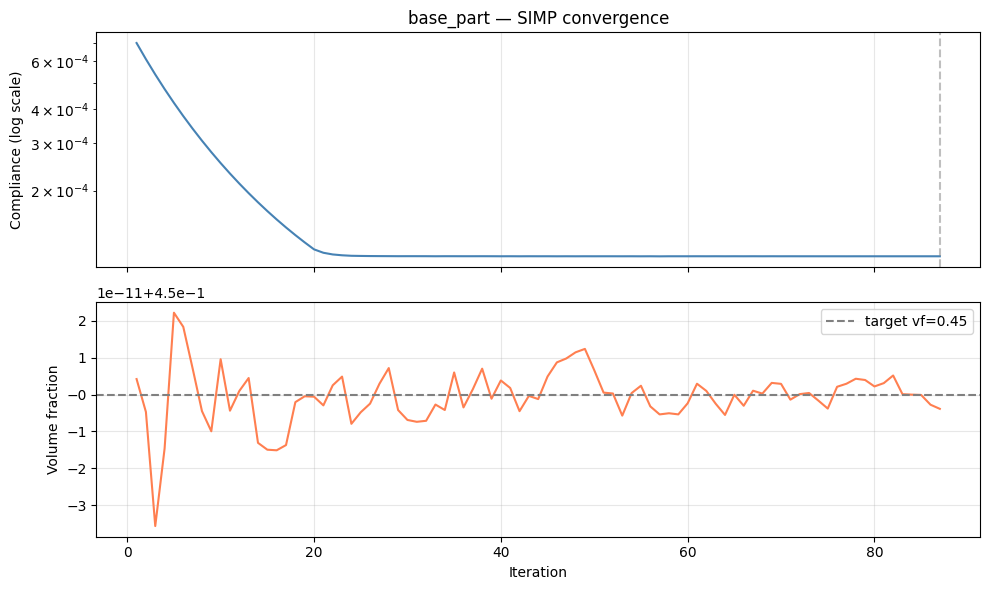

Convergence plot: outputs/reports/base_part_convergence.png


In [12]:
# Cell 4 — Plot compliance and volume fraction history
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

iters = np.arange(1, len(result.compliance_history) + 1)

ax1.semilogy(iters, result.compliance_history, color="steelblue", linewidth=1.5)
ax1.set_ylabel("Compliance (log scale)")
ax1.set_title(f"{part_name} — SIMP convergence")
ax1.axvline(result.n_iterations, color="gray", linestyle="--", alpha=0.5)
ax1.grid(True, alpha=0.3)

ax2.plot(iters, result.volume_history, color="coral", linewidth=1.5)
ax2.axhline(config_hard.volume_fraction, color="gray", linestyle="--",
            label=f"target vf={config_hard.volume_fraction}")
ax2.set_ylabel("Volume fraction")
ax2.set_xlabel("Iteration")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
conv_path = report_dir / f"{part_name}_convergence.png"
plt.savefig(conv_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Convergence plot: {conv_path}")

Cell 5 — Final density render

In [13]:
# Cell 5 — Render final density field with threshold isosurface
if not RENDER_PLOTS:
    print("Skipping render — set RENDER_PLOTS=True after fixing display")
    # Still compute solid fraction without rendering
    import numpy as np
    rho_final = result.density_path
    print(f"Density field written to: {rho_final}")
else:
    import pyvista as pv
    from pathlib import Path

    pv.OFF_SCREEN = True

    density_mesh = pv.read(str(result.density_path))

    pl = pv.Plotter(shape=(1, 2))

    pl.subplot(0, 0)
    pl.add_mesh(density_mesh, scalars="density", cmap="bone",
                clim=[0, 1], show_edges=False)
    pl.add_text("Full density field", font_size=10)
    pl.view_isometric()

    solid = density_mesh.threshold(0.5, scalars="density")

    pl.subplot(0, 1)
    pl.add_mesh(solid, color="lightsteelblue", show_edges=True)
    pl.add_text("Thresholded (ρ > 0.5)", font_size=10)
    pl.view_isometric()

    final_png = report_dir / f"{part_name}_density_final.png"
    pl.screenshot(str(final_png))
    pl.close()
    print(f"Final density render: {final_png}")

    solid_fraction = solid.n_cells / density_mesh.n_cells
    print(f"Solid elements (ρ>0.5): {solid.n_cells:,} / "
          f"{density_mesh.n_cells:,} ({solid_fraction*100:.1f}%)")

Skipping render — set RENDER_PLOTS=True after fixing display
Density field written to: outputs/meshes/base_part_density.xdmf


Cell 6 — Write Stage 4 handoff

In [14]:
# Cell 6 — Handoff for 05_stl_export.ipynb
import json
from pathlib import Path

handoff_out = {
    "stage":              "04_simp",
    "part_name":          part_name,
    "density_path":       str(result.density_path),
    "xdmf_path":          str(xdmf_path),
    "n_iterations":       result.n_iterations,
    "converged":          result.converged,
    "final_compliance":   result.final_compliance,
    "final_volume_frac":  result.final_volume_frac,
    "duration_s":         result.duration_s,
    "config": {
        "volume_fraction": config_hard.volume_fraction,
        "penal":           config_hard.penal,
        "filter_radius":   config_hard.filter_radius,
        "convergence_tol": config_hard.convergence_tol,
    },
    "material":           material,
    "load_hints":         load_hints,
}

handoff_path_out = Path("outputs/meshes") / f"{part_name}_stage04.json"
handoff_path_out.write_text(json.dumps(handoff_out, indent=2))
print(f"Handoff written: {handoff_path_out}")
print(json.dumps(handoff_out, indent=2))

Handoff written: outputs/meshes/base_part_stage04.json
{
  "stage": "04_simp",
  "part_name": "base_part",
  "density_path": "outputs/meshes/base_part_density.xdmf",
  "xdmf_path": "outputs/meshes/opt_domain.xdmf",
  "n_iterations": 87,
  "converged": true,
  "final_compliance": 0.00011452995859397973,
  "final_volume_frac": 0.44999999999611384,
  "duration_s": 55.866,
  "config": {
    "volume_fraction": 0.45,
    "penal": 3.0,
    "filter_radius": 8.0,
    "convergence_tol": 0.002
  },
  "material": {
    "youngs_modulus_pa": 210000000000.0,
    "poissons_ratio": 0.3,
    "name": "steel"
  },
  "load_hints": {
    "primary_face": "top",
    "load_magnitude_n": 10000.0
  }
}


How Stage 4 connects to Stage 5
Two things travel forward:
density_path — the XDMF file containing the final rho field on the DG0 mesh. Stage 5 reads this, applies a threshold (default 0.5), and runs marching cubes via scikit-image to extract the isosurface as a triangle mesh. The threshold is configurable in Stage 5 — raising it (e.g. 0.6) gives a more conservative, heavier result; lowering it (e.g. 0.4) gives a lighter but more fragile one.
xdmf_path — the original mesh. Stage 5 needs the node coordinates to map the DG0 density field onto a regular voxel grid before marching cubes can run, since marching cubes expects a structured grid rather than an unstructured tet mesh.
The most important parameter connecting Stage 4 to Stage 5 is filter_radius. If it's too small relative to target_element_size, the density field will contain checkerboard noise that marching cubes turns into physically unmakeable thin spikes and disconnected islands in the STL. If your Stage 5 STL looks spiky or has disconnected components, come back here and increase FILTER_RADIUS by 50% and re-run from Cell 3.